# P611 Books Recommendation system 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
from sklearn.preprocessing import LabelEncoder


In [3]:
books_df = pd.read_csv("Books.csv")
users_df = pd.read_csv("Users.csv")
rating_df = pd.read_csv("Ratings.csv")

C:\Users\zabak\AppData\Local\Temp\ipykernel_16344\2812902041.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df = pd.read_csv("Books.csv")


In [4]:
books_df.head()


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
rating_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [7]:
print(books_df.shape)
print(users_df.shape)
print(rating_df.shape)

(271360, 8)
(278858, 3)
(1149780, 3)


In [8]:
# Misssing Values
books_df.isna().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [9]:
users_df.isna().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [10]:
rating_df.isna().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [11]:
# Merging files ()

In [12]:
# merging books and rating 
books_rating_df =  rating_df.merge(books_df, on="ISBN")

In [13]:
books_rating_df.head(3)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...


In [14]:
# merging books_rating_df and users
df = books_rating_df.merge(users_df, on="User-ID")

In [15]:
df.head(3)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0


In [16]:
df.tail(3)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,"quebec, quebec, canada",18.0
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,"mannington, west virginia, usa",38.0
1031135,276721,0590442449,10,Fourth Grade Rats,Jerry Spinelli,1996,Scholastic,http://images.amazon.com/images/P/0590442449.0...,http://images.amazon.com/images/P/0590442449.0...,http://images.amazon.com/images/P/0590442449.0...,"providence, rhode island, usa",14.0


STEP 1 :Data Cleaning & Handling Missing Values

In [17]:
df.shape

(1031136, 12)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031136 entries, 0 to 1031135
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   User-ID              1031136 non-null  int64  
 1   ISBN                 1031136 non-null  object 
 2   Book-Rating          1031136 non-null  int64  
 3   Book-Title           1031136 non-null  object 
 4   Book-Author          1031134 non-null  object 
 5   Year-Of-Publication  1031136 non-null  object 
 6   Publisher            1031134 non-null  object 
 7   Image-URL-S          1031136 non-null  object 
 8   Image-URL-M          1031136 non-null  object 
 9   Image-URL-L          1031132 non-null  object 
 10  Location             1031136 non-null  object 
 11  Age                  753301 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 94.4+ MB


In [19]:
# 
df.describe(include='all')


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
count,1.031136e+06,1031136,1.031136e+06,1031136,1031134,1031136.0,1031134,1031136,1031136,1031132,1031136,753301.000000
unique,NaN,270151,NaN,241071,101587,202.0,16729,269842,269842,269839,22480,NaN
top,NaN,0971880107,NaN,Wild Animus,Stephen King,2002.0,Ballantine Books,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,"toronto, ontario, canada",NaN
freq,NaN,2502,NaN,2502,10053,87276.0,34724,2502,2502,2502,14782,NaN
mean,1.405945e+05,NaN,2.839051e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.397648
std,8.052466e+04,NaN,3.854157e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.098254
min,2.000000e+00,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,7.041500e+04,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.000000
50%,1.412100e+05,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000
75%,2.114260e+05,NaN,7.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.isna().sum()

User-ID                     0
ISBN                        0
Book-Rating                 0
Book-Title                  0
Book-Author                 2
Year-Of-Publication         0
Publisher                   2
Image-URL-S                 0
Image-URL-M                 0
Image-URL-L                 4
Location                    0
Age                    277835
dtype: int64

In [22]:
# Fill missing values
df['Book-Author'] = df['Book-Author'].fillna("Unknown")
df['Publisher'] = df['Publisher'].fillna("Unknown")

In [23]:
# Handle Age ( filling missing values with median )
df['Age'] = df['Age'].fillna(df['Age'].median())

In [24]:
df.isna().sum()

User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            4
Location               0
Age                    0
dtype: int64

In [25]:
# Value Counts of Books
df['Book-Title'].value_counts().head(10)


Book-Title
Wild Animus                                        2502
The Lovely Bones: A Novel                          1295
The Da Vinci Code                                   898
A Painted House                                     838
The Nanny Diaries: A Novel                          828
Bridget Jones's Diary                               815
The Secret Life of Bees                             774
Divine Secrets of the Ya-Ya Sisterhood: A Novel     740
The Red Tent (Bestselling Backlist)                 723
Angels &amp; Demons                                 670
Name: count, dtype: int64

In [26]:
# Value Counts of Users
df['User-ID'].value_counts().head(10)


User-ID
11676     11144
198711     6456
153662     5814
98391      5779
35859      5646
212898     4289
278418     3996
76352      3329
110973     2971
235105     2943
Name: count, dtype: int64

In [27]:
# Value Counts of Authors
df['Book-Author'].value_counts().head(10)


Book-Author
Stephen King          10053
Nora Roberts           8429
John Grisham           6010
James Patterson        5845
Mary Higgins Clark     4777
Dean R. Koontz         4313
Tom Clancy             4036
Danielle Steel         3726
Sue Grafton            3457
Janet Evanovich        3350
Name: count, dtype: int64

STEP 2 : Outlier Detection and Handling 

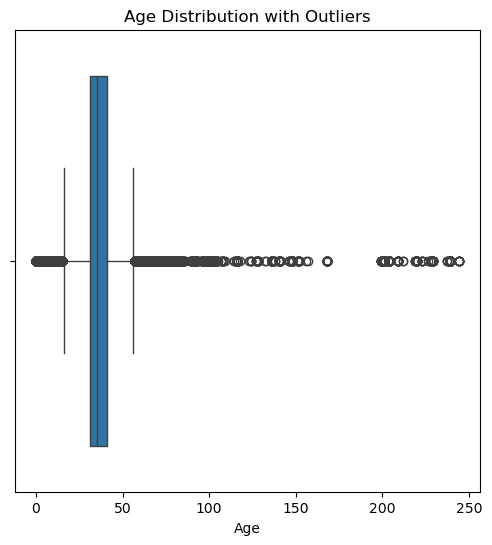

In [28]:
# Boxplot
plt.figure(figsize=(6,6))
sns.boxplot(x=df['Age'])
plt.title("Age Distribution with Outliers")
plt.show()


In [29]:
# Handling outliers by keeping the age range realistic 
df = df[(df['Age'] >= 5) & (df['Age'] <= 90)]


- Boxplot of Age shows age is between 0 to 250
- we handled age by makeing it  0-90 age range which is more realistic 

Step 3 :Visualization 

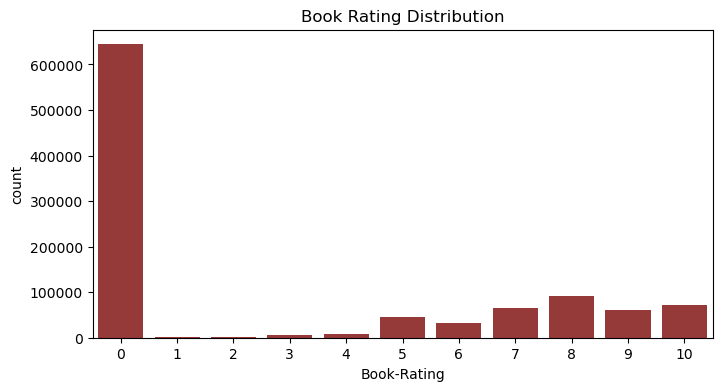

In [30]:
# Countplot of Book Rating Distribution
plt.figure(figsize=(8,4))
sns.countplot(x=df['Book-Rating'], color='brown')
plt.title("Book Rating Distribution")
plt.show()


- Most ratings are 0, which means the user interacted with the book but didn’t give a rating.
- Ratings from 1 to 10 are much less common, and few users gave 9 or 10.

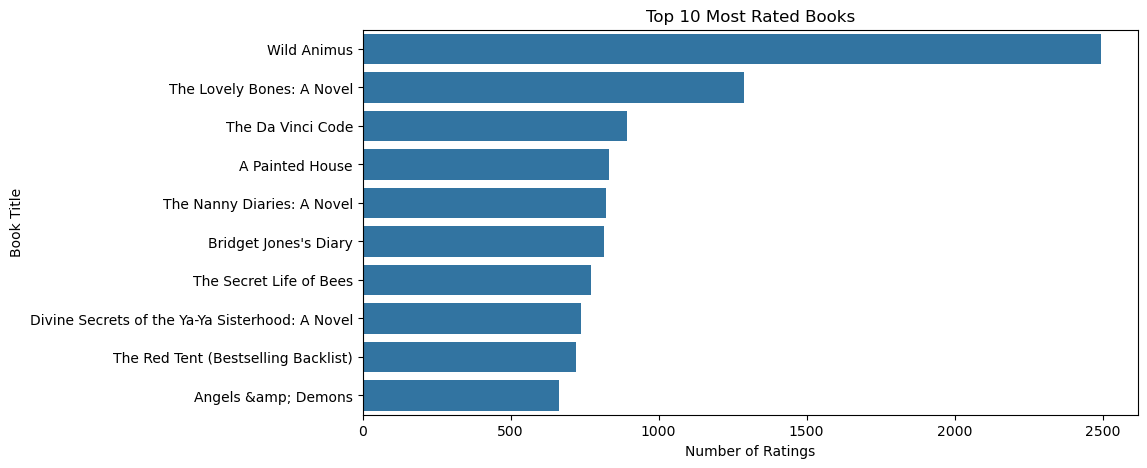

In [31]:
# Top 10 Most Rated Books
top_books = df['Book-Title'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_books.values, y=top_books.index)
plt.title("Top 10 Most Rated Books")
plt.xlabel("Number of Ratings")
plt.ylabel("Book Title")
plt.show()


-  Barplot shows the top 10 most rated books
-  Books like Wild Animus and other are most rated which can be infered as most popular 


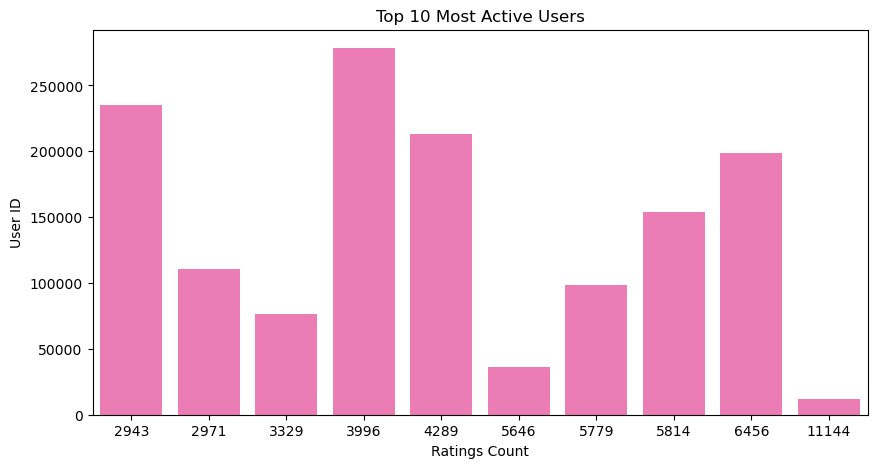

In [32]:
# Most Active Users
top_users = df['User-ID'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_users.values, y=top_users.index, color='hotpink')
plt.title("Top 10 Most Active Users")
plt.xlabel("Ratings Count")
plt.ylabel("User ID")
plt.show()


- The barplot shows the top 10 most active users based on the number of ratings they have given
- Users with higher counts are more active meaning they have rated more books than others

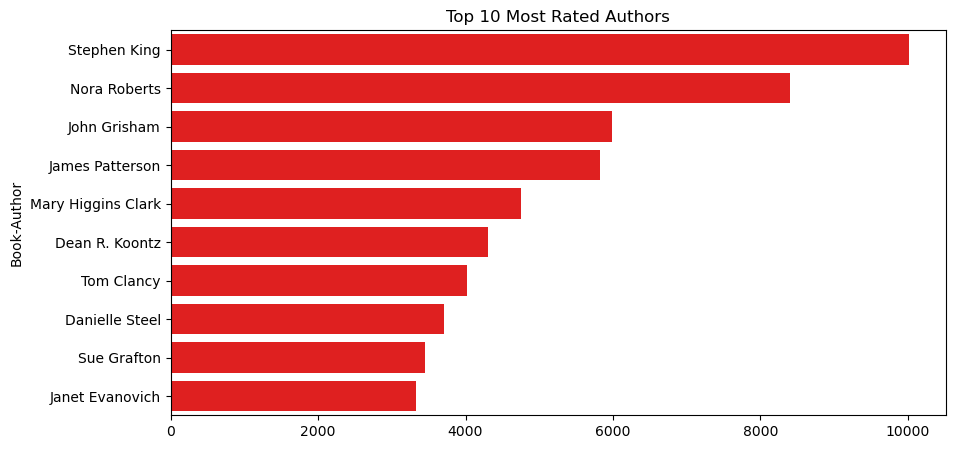

In [33]:
# MOst Rated Book Authors
top_authors = df['Book-Author'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_authors.values, y=top_authors.index, color='red')
plt.title("Top 10 Most Rated Authors")
plt.show()


- Barplot shows the top 10 most rated authors
- Authors with more ratings are more popular  

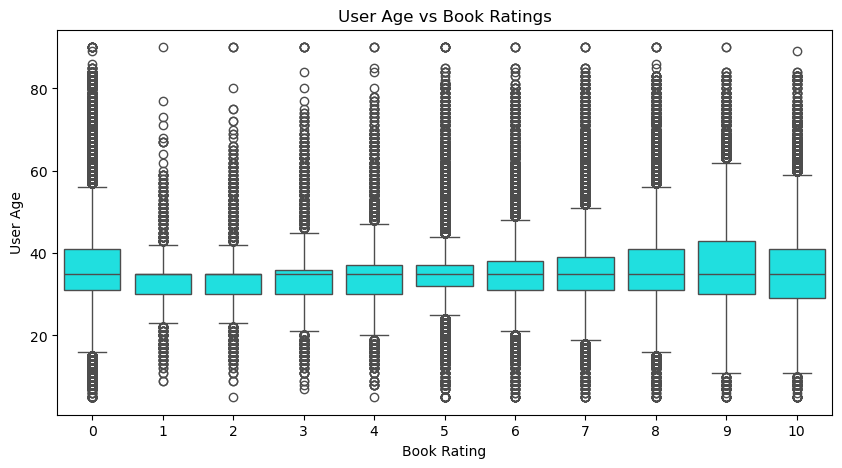

In [34]:
# Boxplot of Usee age vs Book ratings 
plt.figure(figsize=(10,5))
sns.boxplot(x='Book-Rating', y='Age', data=df, color='cyan')
plt.title("User Age vs Book Ratings")
plt.xlabel("Book Rating")
plt.ylabel("User Age")
plt.show()


- The median line in each box shows the typical age for that rating, which is 30 to 40
- Outliers can be seen as points outside, showing unusual ages

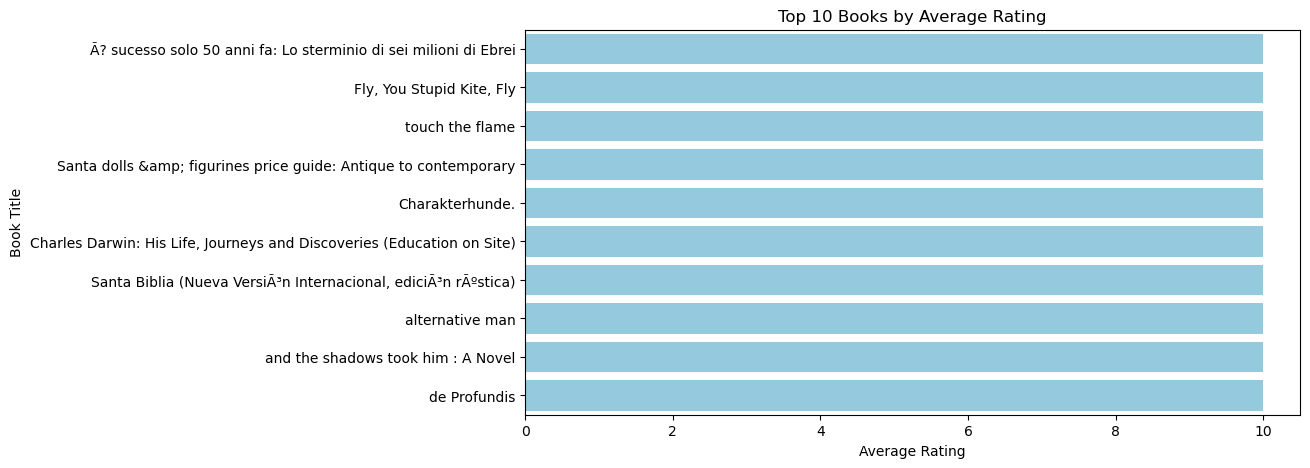

In [35]:
# Top 10 Books by Average Rating
avg_rating_per_book = df.groupby('Book-Title')['Book-Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_rating_per_book.values, y=avg_rating_per_book.index,color='skyblue')
plt.title("Top 10 Books by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Book Title")
plt.show()

- The barplot shows the top 20 books by average rating
- Books with higher average ratings are considered more liked or appreciated by users

C:\Users\zabak\AppData\Local\Temp\ipykernel_16344\2500666936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


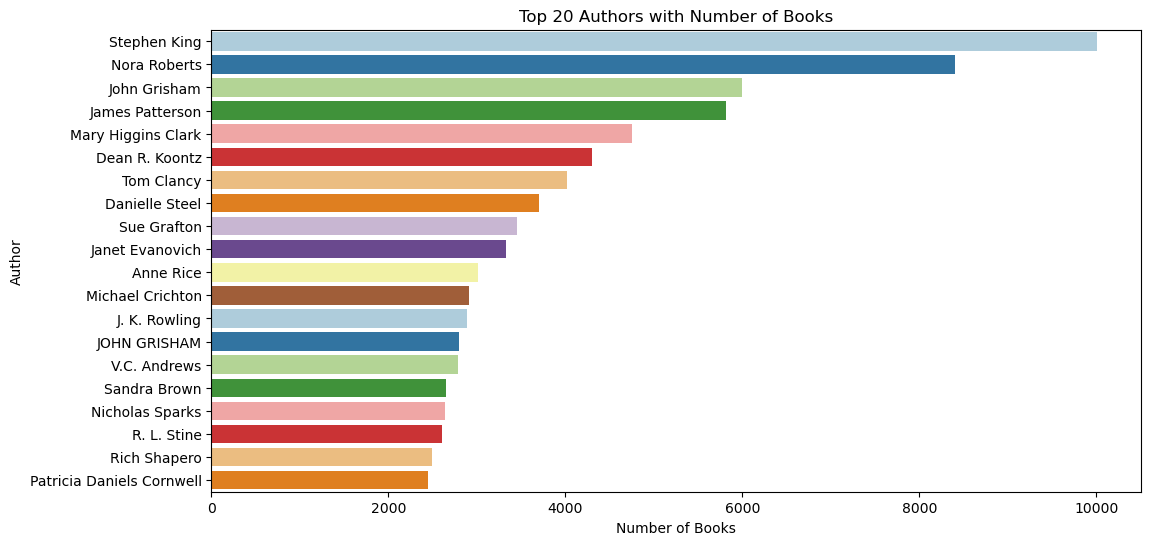

In [36]:
# Top 20 Authors by Number of Books
plt.figure(figsize=(12,6))
sns.countplot(
    y="Book-Author",
    data=df,
    order=df['Book-Author'].value_counts().index[0:20],
    palette='Paired' )
plt.title("Top 20 Authors with Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.show()

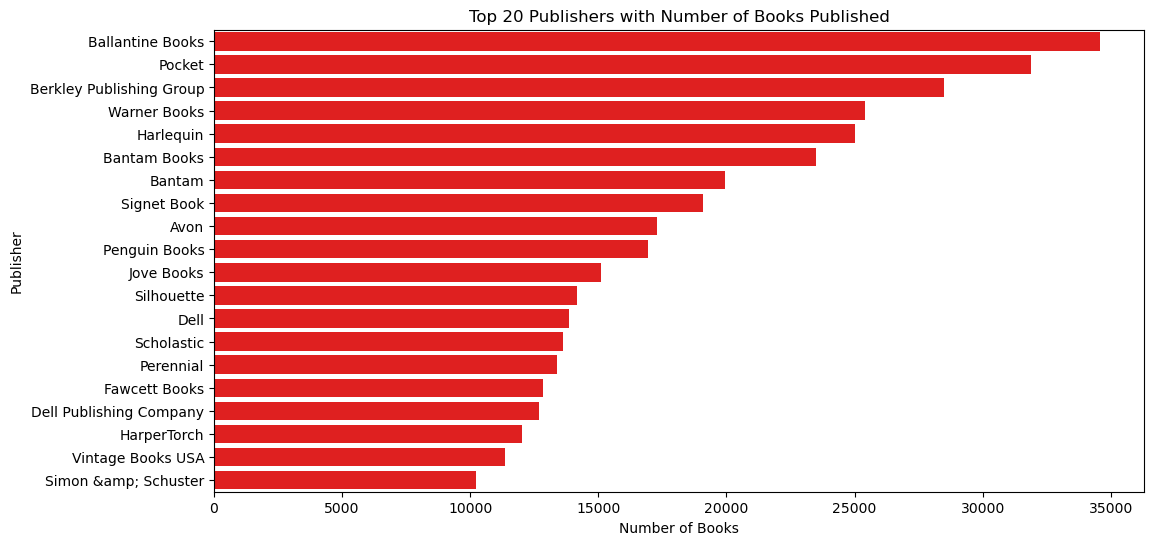

In [37]:
# Top 20 Publishers by Number of Books
plt.figure(figsize=(12,6))
sns.countplot(y="Publisher",data=df,order=df['Publisher'].value_counts().index[0:20],color='red' )
plt.title("Top 20 Publishers with Number of Books Published")
plt.xlabel("Number of Books")
plt.ylabel("Publisher")
plt.show()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1026157 entries, 0 to 1031135
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   User-ID              1026157 non-null  int64  
 1   ISBN                 1026157 non-null  object 
 2   Book-Rating          1026157 non-null  int64  
 3   Book-Title           1026157 non-null  object 
 4   Book-Author          1026157 non-null  object 
 5   Year-Of-Publication  1026157 non-null  object 
 6   Publisher            1026157 non-null  object 
 7   Image-URL-S          1026157 non-null  object 
 8   Image-URL-M          1026157 non-null  object 
 9   Image-URL-L          1026153 non-null  object 
 10  Location             1026157 non-null  object 
 11  Age                  1026157 non-null  float64
dtypes: float64(1), int64(2), object(9)
memory usage: 101.8+ MB


Step 4  : Feature Engineering

In [39]:
# Important features
df1 = df[['User-ID', 'ISBN', 'Book-Rating', 
          'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
          'Age', 'Location']].copy()

In [40]:
df1.head(3)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Age,Location
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,35.0,"tyler, texas, usa"
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,35.0,"seattle, washington, usa"
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,16.0,"h, new south wales, australia"


In [41]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1026157 entries, 0 to 1031135
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   User-ID              1026157 non-null  int64  
 1   ISBN                 1026157 non-null  object 
 2   Book-Rating          1026157 non-null  int64  
 3   Book-Title           1026157 non-null  object 
 4   Book-Author          1026157 non-null  object 
 5   Year-Of-Publication  1026157 non-null  object 
 6   Publisher            1026157 non-null  object 
 7   Age                  1026157 non-null  float64
 8   Location             1026157 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 78.3+ MB


In [42]:
df1.sample(10)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Age,Location
133212,33974,0449202208,7,Columbella,Phyllis A. Whitney,1981,Ivy Books,24.0,"barnhart, missouri, usa"
849238,229632,0689308477,0,Keeper of the Isis Light,Monica Hughes,1981,Simon &amp; Schuster (J),23.0,"duchesne, utah, usa"
28315,7478,0312104324,8,The Bluestocking: The Story of the Famous Forr...,David Delman,1994,St Martins Pr,34.0,"culver city, california, usa"
567648,153662,0373708297,0,"Fathers And Sons (Harlequin Superromance, 829)",Carolyn McSparren,1999,Harlequin,44.0,"ft. stewart, georgia, usa"
571233,153662,0821771949,0,A Country Courtship (Zebra Regency Romance),Donna Simpson,2002,Kensington Publishing Corporation,44.0,"ft. stewart, georgia, usa"
66807,16634,0399143939,0,Trick of Light,David Hunt,1998,Putnam Pub Group,42.0,"little rock, arkansas, usa"
628446,170742,0380710404,0,The Secret of the Indian (Indian in the Cupboard),Lynne Reid Banks,1999,HarperTrophy,41.0,"o`fallon, missouri, usa"
597575,162469,2253140228,5,Les gÃ?Â©nies de l'arnaque,Pierre Bellemare,1996,LGF,29.0,"belfaux, fribourg, switzerland"
953293,253859,8401462215,5,Los Perros de La Guerra,Frederick Forsyth,1999,"Plaza &amp; Janes Editores, S.A.",38.0,"vitoria-gasteiz, alava, spain"
354842,95359,0821749471,4,Deadly Diet,Vincent Courtney,1995,Kensington Pub Corp (Mm),33.0,"charleston, west virginia, usa"


In [43]:
df1.shape

(1026157, 9)

In [44]:
# Separating city, state, country from Location 
# First, split by commas
loc_split = df1['Location'].str.split(',', n=2, expand=True)

# Fill missing parts with "Unknown"
loc_split = loc_split.fillna('Unknown')

# Strip spaces
loc_split = loc_split.applymap(lambda x: x.strip())

# Rename columns
loc_split.columns = ['City', 'State', 'Country']

# If Country contains multiple parts  take only the last part
loc_split['Country'] = loc_split['Country'].apply(lambda x: x.split()[-1] if len(x.split())>1 else x)

# Add back to df1
df1[['City','State','Country']] = loc_split

# Drop original Location
df1.drop(columns=['Location'], inplace=True)


C:\Users\zabak\AppData\Local\Temp\ipykernel_16344\3935373883.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  loc_split = loc_split.applymap(lambda x: x.strip())


In [45]:
# converting and filling missing values
df1['Year-Of-Publication'] = pd.to_numeric(df1['Year-Of-Publication'], errors='coerce')
df1['Year-Of-Publication'] = df1['Year-Of-Publication'].fillna(df1['Year-Of-Publication'].median())



In [46]:
# Encode Categorical Features
# Encode using LabelEncoder

In [47]:
# Initialize encoders
le_author = LabelEncoder()
le_publisher = LabelEncoder()
le_city = LabelEncoder()
le_state = LabelEncoder()
le_country = LabelEncoder()
le_isbn = LabelEncoder()

In [48]:
# Encode categorical columns
df1['Book-Author'] = le_author.fit_transform(df1['Book-Author'])
df1['Publisher'] = le_publisher.fit_transform(df1['Publisher'])
df1['City'] = le_city.fit_transform(df1['City'])
df1['State'] = le_state.fit_transform(df1['State'])
df1['Country'] = le_country.fit_transform(df1['Country'])
df1['ISBN'] = le_isbn.fit_transform(df1['ISBN'])


In [49]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1026157 entries, 0 to 1031135
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   User-ID              1026157 non-null  int64  
 1   ISBN                 1026157 non-null  int64  
 2   Book-Rating          1026157 non-null  int64  
 3   Book-Title           1026157 non-null  object 
 4   Book-Author          1026157 non-null  int64  
 5   Year-Of-Publication  1026157 non-null  float64
 6   Publisher            1026157 non-null  int64  
 7   Age                  1026157 non-null  float64
 8   City                 1026157 non-null  int64  
 9   State                1026157 non-null  int64  
 10  Country              1026157 non-null  int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 93.9+ MB


In [50]:
df1.sample(5)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Age,City,State,Country
1004196,268622,38462,0,Roses Are Red,42677,2000.0,8758,36.0,13293,1140,256
654821,177090,61733,0,The Reader,8669,1999.0,15601,37.0,612,1058,256
1007697,269566,91531,0,Red Phoenix,56739,1990.0,15810,9.0,11602,1831,256
649958,175101,132771,0,The TITANIC DISASTER HEARINGS,95639,1998.0,11670,61.0,12745,553,256
37433,11192,257210,0,Love Mail. Roman.,12372,2002.0,11580,49.0,14418,1420,91


In [51]:
# Filter Sparse Users and Books

In [52]:
#In real datasets, many users rate very few books, and many books are rated by very few users.
#Collaborative Filtering (CF) relies on user-item interactions. Sparse data can:
#Make similarity calculations noisy
#Slow down model training
#Reduce recommendation quality

#Filtering ensures:
#Each user has enough ratings to learn their preferences
#Each book has enough ratings to be meaningful

In [53]:
# Filter Users
# Count ratings per user
user_counts = df1['User-ID'].value_counts()

# Keep only users with 5 or more ratings
users_to_keep = user_counts[user_counts >= 10].index
df1 = df1[df1['User-ID'].isin(users_to_keep)]


In [54]:
#Filter Books 
# Count ratings per book
book_counts = df1['ISBN'].value_counts()

# Keep only books with 10 or more ratings
books_to_keep = book_counts[book_counts >= 20].index
df1 = df1[df1['ISBN'].isin(books_to_keep)]


In [55]:
df1.shape

(289043, 11)

In [56]:
# Pivot table (User-Item Matrix)

In [57]:
# Create pivot table
books_pivot = df1.pivot_table(index='User-ID', columns='Book-Title', values='Book-Rating').fillna(0)

In [58]:
books_pivot.shape

(11100, 5330)

In [59]:
books_pivot.sample(5)

Book-Title,'Salem's Lot,10 Lb. Penalty,"14,000 Things to Be Happy About",16 Lighthouse Road,1984,1st to Die: A Novel,2001: A Space Odyssey,2010: Odyssey Two,203 Ways to Drive a Man Wild in Bed,204 Rosewood Lane,...,Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,Zlata's Diary: A Child's Life in Sarajevo,Zodiac: The Eco-Thriller,Zombies of the Gene Pool,Zoya,"\ Lamb to the Slaughter and Other Stories (Penguin 60s S.)""","\O\"" Is for Outlaw""","\Surely You're Joking, Mr. Feynman!\"": Adventures of a Curious Character""",e,stardust
User-ID,,,,,,,,,,,,,,,,,,,,,
55006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60337,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
259371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
201404,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
273167,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
from scipy.sparse import csr_matrix
# Pivot table (User-Item Matrix)
# Convert to sparse matrix
book_sparse = csr_matrix(books_pivot.values)

In [61]:
book_sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 98385 stored elements and shape (11100, 5330)>

### Popularity Based Recommender System

In [62]:
ratings_with_name=rating_df.merge(books_df, on='ISBN')

In [63]:
ratings_with_name.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


In [64]:
### Book name with number of ratings
num_rating_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'}, inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [65]:
ratings_with_name['Book-Rating'] = pd.to_numeric(ratings_with_name['Book-Rating'], errors='coerce')

In [66]:
ratings_with_name['Book-Rating'] = pd.to_numeric(
    ratings_with_name['Book-Rating'], 
    errors='coerce'
)

# Optional: check it really worked
print(ratings_with_name['Book-Rating'].dtype)     
print(ratings_with_name['Book-Rating'].head(20))

int64
0     0
1     5
2     0
3     3
4     6
5     0
6     7
7     0
8     0
9     0
10    0
11    0
12    0
13    9
14    0
15    0
16    9
17    8
18    7
19    0
Name: Book-Rating, dtype: int64


In [67]:
avg_rating_df = (
    ratings_with_name
    .groupby('Book-Title')['Book-Rating']
    .mean()
    .reset_index()
    .rename(columns={'Book-Rating': 'avg_rating'})
)

avg_rating_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [68]:
popular_df = num_rating_df.merge(avg_rating_df,on='Book-Title')
popular_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [69]:
popular_df = popular_df[popular_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(50)

In [70]:
popular_df

,Book-Title,num_ratings,avg_rating
80434,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
80422,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
80441,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
80426,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
80414,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453
191612,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117
187377,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370
80445,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652
211384,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769
219741,To Kill a Mockingbird,510,4.700000


In [71]:
popular_df = popular_df.merge(books_df,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']]

In [72]:
popular_df['Image-URL-M'][0]

'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'

## Collaborative Filtering Based Recommender System

In [73]:
## Filtering basis on users who have given more than 200 ratings
x = ratings_with_name.groupby('User-ID').count()['Book-Rating'] > 200
knowledgeable_users = x[x].index

In [74]:
## below is those user who rated minimum 200 books
knowledgeable_users

Index([   254,   2276,   2766,   2977,   3363,   4017,   4385,   6251,   6323,
         6543,
       ...
       271705, 273979, 274004, 274061, 274301, 274308, 275970, 277427, 277639,
       278418],
      dtype='int64', name='User-ID', length=811)

In [75]:
## Filtering basis on knowledgeable users
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(knowledgeable_users)]

In [76]:
filtered_rating

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
1151,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...,http://images.amazon.com/images/P/0026217457.0...,http://images.amazon.com/images/P/0026217457.0...
1152,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...,http://images.amazon.com/images/P/003008685X.0...,http://images.amazon.com/images/P/003008685X.0...
1153,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...,http://images.amazon.com/images/P/0030615321.0...,http://images.amazon.com/images/P/0030615321.0...
1154,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...,http://images.amazon.com/images/P/0060002050.0...,http://images.amazon.com/images/P/0060002050.0...
...,...,...,...,...,...,...,...,...,...,...
1029357,275970,1931868123,0,There's a Porcupine in My Outhouse: Misadventu...,Mike Tougias,2002,Capital Books (VA),http://images.amazon.com/images/P/1931868123.0...,http://images.amazon.com/images/P/1931868123.0...,http://images.amazon.com/images/P/1931868123.0...
1029358,275970,3411086211,10,Die Biene.,Sybil GrÃ?Â¤fin SchÃ?Â¶nfeldt,1993,"Bibliographisches Institut, Mannheim",http://images.amazon.com/images/P/3411086211.0...,http://images.amazon.com/images/P/3411086211.0...,http://images.amazon.com/images/P/3411086211.0...
1029359,275970,3829021860,0,The Penis Book,Joseph Cohen,1999,Konemann,http://images.amazon.com/images/P/3829021860.0...,http://images.amazon.com/images/P/3829021860.0...,http://images.amazon.com/images/P/3829021860.0...
1029360,275970,4770019572,0,Musashi,Eiji Yoshikawa,1995,Kodansha International (JPN),http://images.amazon.com/images/P/4770019572.0...,http://images.amazon.com/images/P/4770019572.0...,http://images.amazon.com/images/P/4770019572.0...


In [77]:
y = filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50
famous_books = y[y].index

In [78]:
famous_books

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Day Late and a Dollar Short', 'A Fine Balance',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='object', name='Book-Title', length=706)

In [79]:
### we got rows where the book title is in famous books
filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
1163,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...
1165,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...
1168,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...
1174,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,http://images.amazon.com/images/P/006440188X.0...,http://images.amazon.com/images/P/006440188X.0...
...,...,...,...,...,...,...,...,...,...,...
1029196,275970,1400031354,0,Tears of the Giraffe (No.1 Ladies Detective Ag...,Alexander McCall Smith,2002,Anchor,http://images.amazon.com/images/P/1400031354.0...,http://images.amazon.com/images/P/1400031354.0...,http://images.amazon.com/images/P/1400031354.0...
1029197,275970,1400031362,0,Morality for Beautiful Girls (No.1 Ladies Dete...,Alexander McCall Smith,2002,Anchor,http://images.amazon.com/images/P/1400031362.0...,http://images.amazon.com/images/P/1400031362.0...,http://images.amazon.com/images/P/1400031362.0...
1029270,275970,1573229725,0,Fingersmith,Sarah Waters,2002,Riverhead Books,http://images.amazon.com/images/P/1573229725.0...,http://images.amazon.com/images/P/1573229725.0...,http://images.amazon.com/images/P/1573229725.0...
1029309,275970,1586210661,9,Me Talk Pretty One Day,David Sedaris,2001,Time Warner Audio Major,http://images.amazon.com/images/P/1586210661.0...,http://images.amazon.com/images/P/1586210661.0...,http://images.amazon.com/images/P/1586210661.0...


In [80]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [81]:
## in this we used pivot table
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [82]:
pt.fillna(0,inplace=True)

In [83]:
### there is those users who rated over 200 books  and books on which atleast 50 ratings are given
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
from sklearn.metrics.pairwise import cosine_similarity

In [85]:
similarity_scores = cosine_similarity(pt)

In [86]:
## we have 
similarity_scores.shape

(706, 706)

In [87]:
def recommend(book_name):
    # index fetch
    index = np.where(pt.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:5]
    
    data = []
    for i in similar_items:
        item = []
        temp_df = books_df[books_df['Book-Title'] == pt.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
        
        data.append(item)
    
    return data

In [88]:
recommend('1984')

[['Animal Farm',
  'George Orwell',
  'http://images.amazon.com/images/P/0451526341.01.MZZZZZZZ.jpg'],
 ["The Handmaid's Tale",
  'Margaret Atwood',
  'http://images.amazon.com/images/P/0449212602.01.MZZZZZZZ.jpg'],
 ['Brave New World',
  'Aldous Huxley',
  'http://images.amazon.com/images/P/0060809833.01.MZZZZZZZ.jpg'],
 ['The Vampire Lestat (Vampire Chronicles, Book II)',
  'ANNE RICE',
  'http://images.amazon.com/images/P/0345313860.01.MZZZZZZZ.jpg']]

In [89]:
pt.index[545]

"The Handmaid's Tale"

In [90]:
import pickle
pickle.dump(popular_df,open('popular.pkl','wb'))

In [91]:
books_df.drop_duplicates('Book-Title')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271354,0449906736,Flashpoints: Promise and Peril in a New World,Robin Wright,1993,Ballantine Books,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [92]:
pickle.dump(pt,open('pt.pkl','wb'))
pickle.dump(books_df,open('books.pkl','wb'))
pickle.dump(similarity_scores,open('similarity_scores.pkl','wb'))